ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [2]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [3]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [4]:
print(f'Dataset shape: {df.shape}')
print(f'Number of customers: {df.shape[0]}')
print(f'Number of features: {df.shape[1]}')

Dataset shape: (8950, 18)
Number of customers: 8950
Number of features: 18


**Check basic information about the dataset using `info()`.**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

**Check summary statistics using `describe()`.**

In [6]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [7]:
df = df.drop('CUST_ID', axis=1)

**Check the missing values in each column.**

In [8]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [9]:
# Fill missing values with the mean of each column
df = df.fillna(df.mean())

**Check the missing values again to make sure they were handled.**

In [10]:
print('Missing values after imputation:')
print(df.isnull().sum())

Missing values after imputation:
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

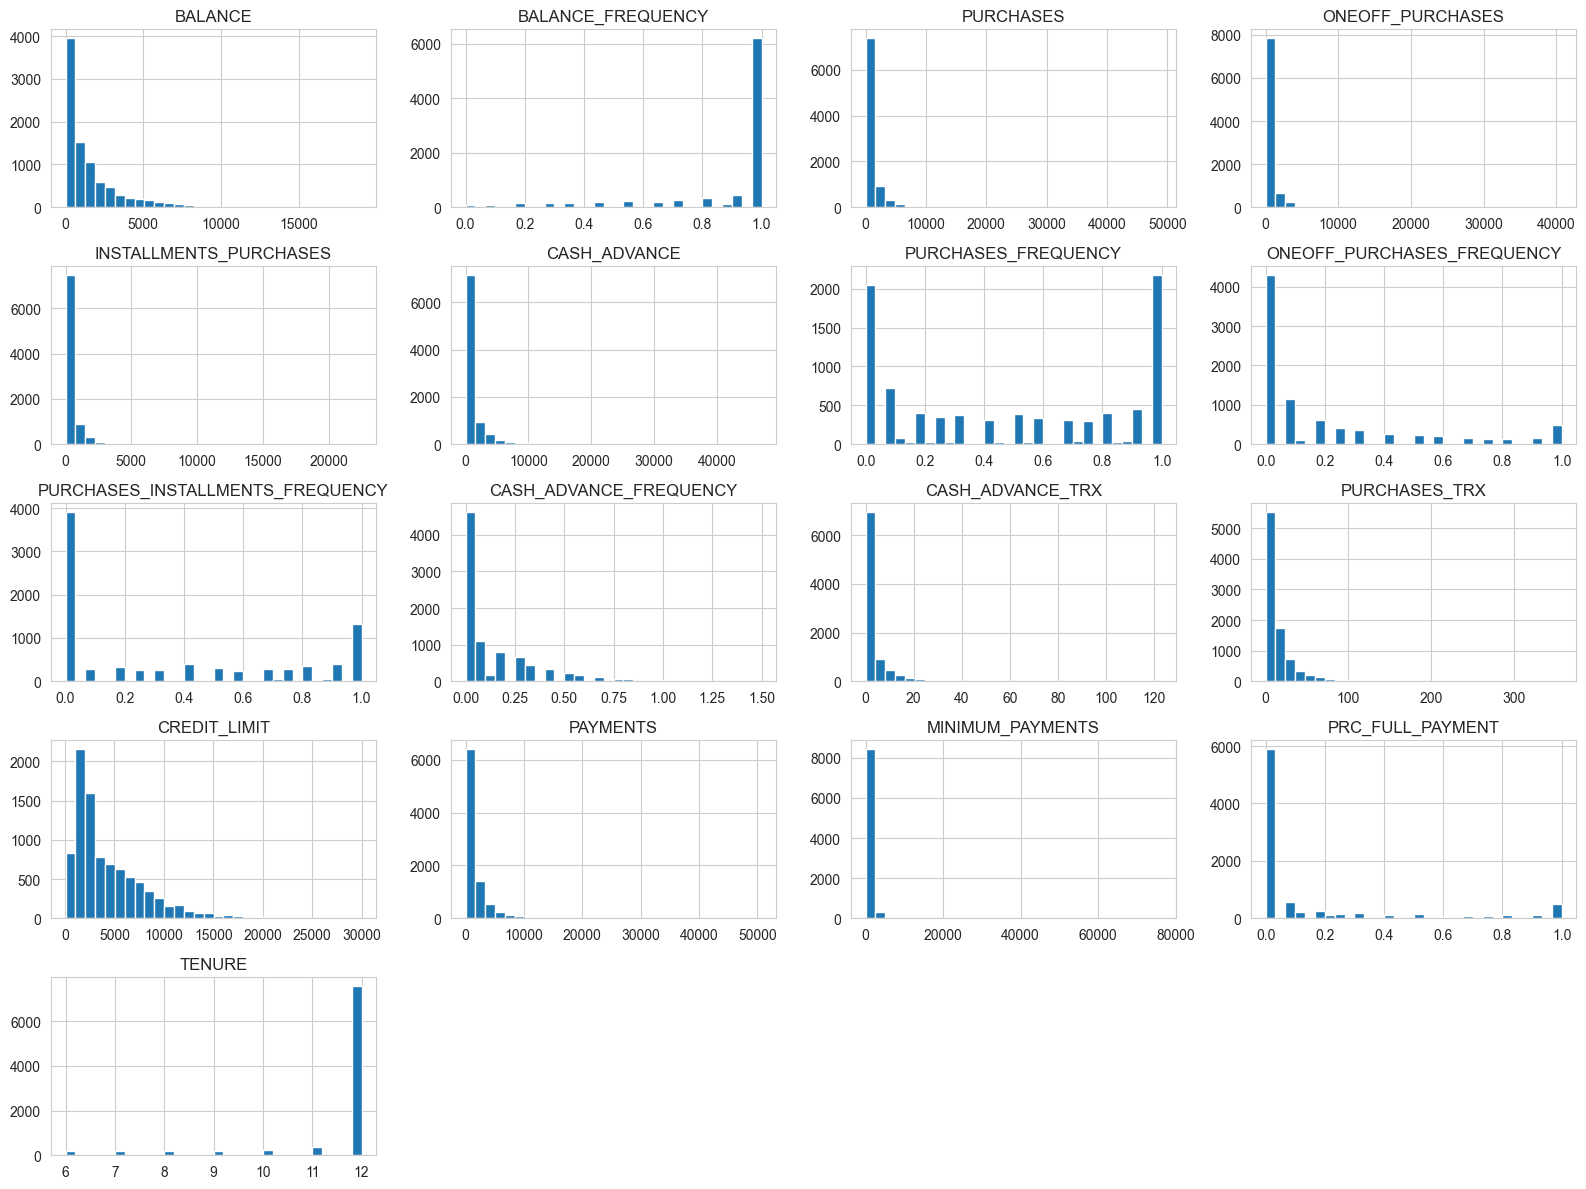

In [11]:
# Create histograms for all numerical columns
df.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

**Create a correlation heatmap to understand relationships between the features.**

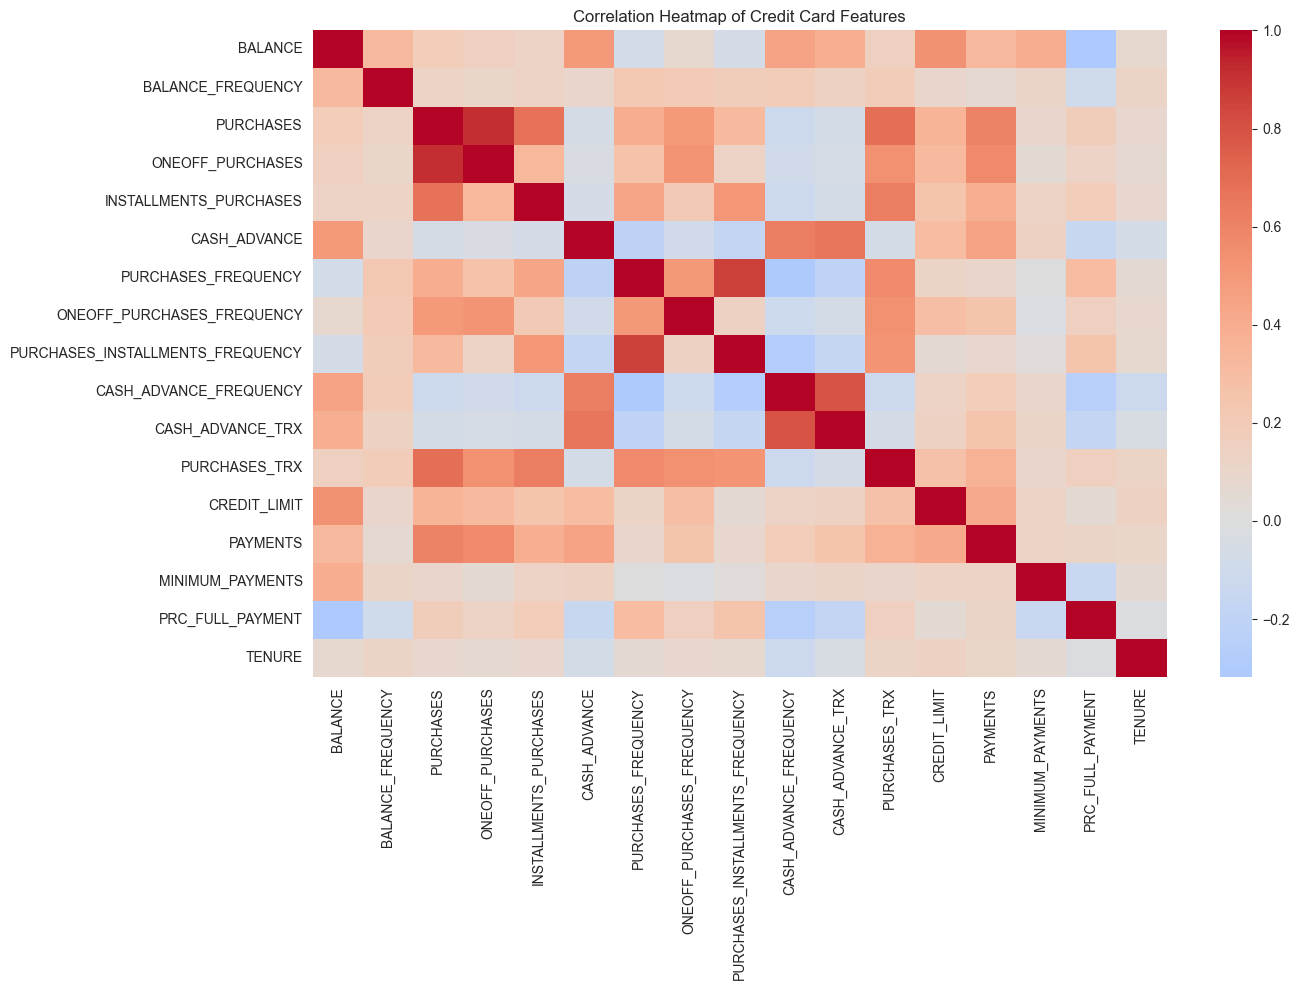

In [12]:
# Create correlation heatmap
plt.figure(figsize=(14, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Credit Card Features')
plt.tight_layout()
plt.show()

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

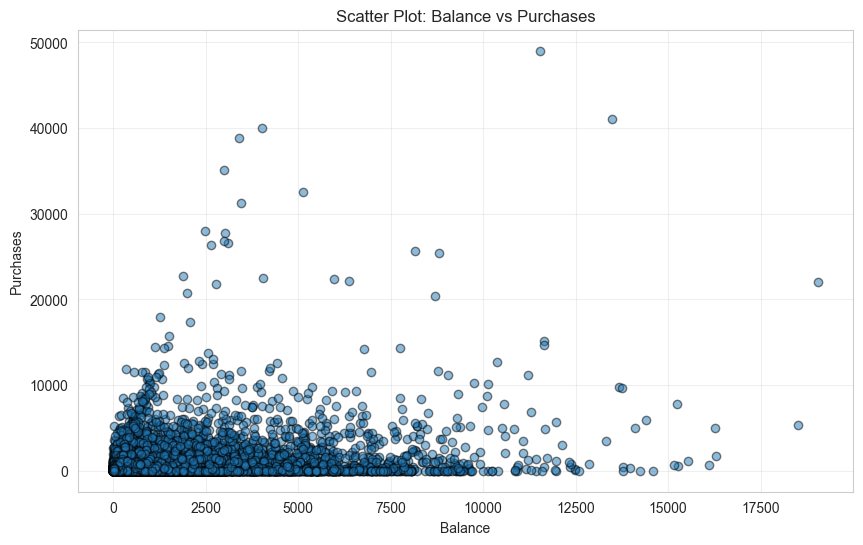

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.5, edgecolors='k')
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title('Scatter Plot: Balance vs Purchases')
plt.grid(True, alpha=0.3)
plt.show()

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

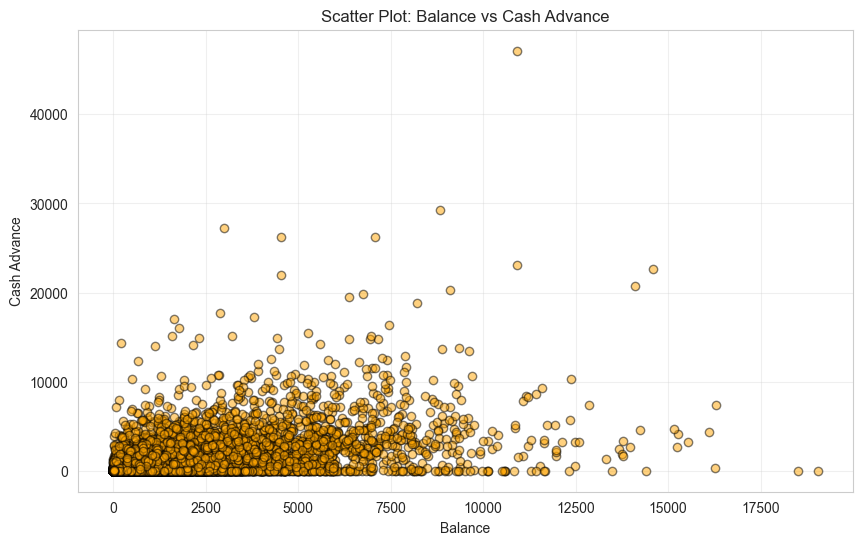

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.5, edgecolors='k', color='orange')
plt.xlabel('Balance')
plt.ylabel('Cash Advance')
plt.title('Scatter Plot: Balance vs Cash Advance')
plt.grid(True, alpha=0.3)
plt.show()

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [15]:
# Scale the data using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [16]:
# Elbow method
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

print('Inertia values for K = 1 to 10:')
for k, inertia in zip(K_range, inertia_values):
    print(f'K={k}: {inertia:.2f}')

Inertia values for K = 1 to 10:
K=1: 152150.00
K=2: 127785.01
K=3: 111986.70
K=4: 99073.94
K=5: 91502.98
K=6: 84852.52
K=7: 79532.33
K=8: 76050.70
K=9: 71087.27
K=10: 66612.69


**Plot the elbow curve.**

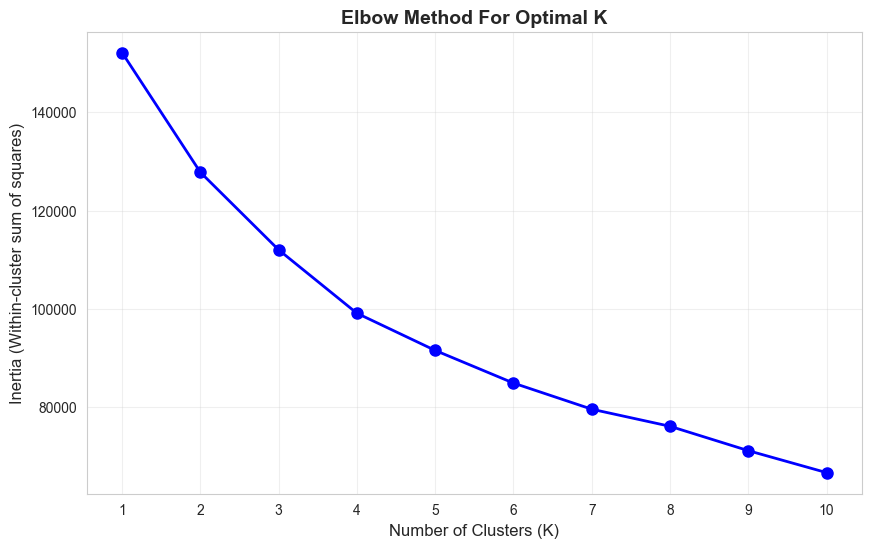

In [17]:
# Plot the elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
plt.title('Elbow Method For Optimal K', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [18]:
# Silhouette score calculation
silhouette_scores = []
K_range_silhouette = range(2, 11)

for k in K_range_silhouette:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

print('Silhouette scores for K = 2 to 10:')
for k, score in zip(K_range_silhouette, silhouette_scores):
    print(f'K={k}: {score:.4f}')

Silhouette scores for K = 2 to 10:
K=2: 0.2100
K=3: 0.2506
K=4: 0.1976
K=5: 0.1932
K=6: 0.2026
K=7: 0.2150
K=8: 0.2081
K=9: 0.2149
K=10: 0.2205


**Plot the silhouette scores.**

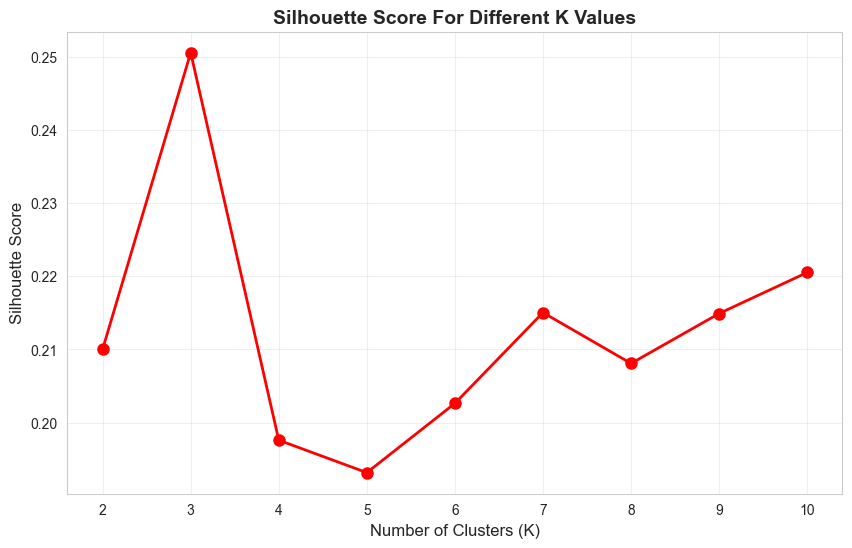

In [19]:
# Plot silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K_range_silhouette, silhouette_scores, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.title('Silhouette Score For Different K Values', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range_silhouette)
plt.show()

**Create a table showing each K value and its silhouette score.**

In [20]:
# Create a table for K values and silhouette scores
silhouette_table = pd.DataFrame({
    'K': list(K_range_silhouette),
    'Silhouette Score': silhouette_scores
})
print(silhouette_table.to_string(index=False))
print(f'\nBest K based on Silhouette Score: K={silhouette_table.loc[silhouette_table["Silhouette Score"].idxmax(), "K"]}')

 K  Silhouette Score
 2          0.210033
 3          0.250556
 4          0.197607
 5          0.193169
 6          0.202639
 7          0.215038
 8          0.208092
 9          0.214912
10          0.220518

Best K based on Silhouette Score: K=3


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [21]:
# Final K-Means model - choosing K=3 based on elbow method and silhouette score
final_k = 3
kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

print(f'Final K-Means model trained with K={final_k}')
print(f'Final Inertia: {kmeans_final.inertia_:.2f}')
print(f'Final Silhouette Score: {silhouette_score(X_scaled, kmeans_final.labels_):.4f}')

Final K-Means model trained with K=3
Final Inertia: 111986.70
Final Silhouette Score: 0.2506


**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [22]:
# Add cluster labels to the original dataframe
df['Cluster'] = kmeans_final.labels_

**Check the first five rows after adding the cluster labels.**

In [23]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,2
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,2
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,2


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [24]:
# Create cluster summary table
cluster_summary = df.groupby('Cluster').mean()
print('Cluster Summary - Mean Values of Each Feature:')
print(cluster_summary)

Cluster Summary - Mean Values of Each Feature:
             BALANCE  BALANCE_FREQUENCY    PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                                  
0        3989.326804           0.957980   384.528277        248.718133   
1        2220.003291           0.981477  4268.520980       2717.828543   
2         799.702576           0.835188   505.532394        253.120131   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                    135.887632   3869.856855             0.232290   
1                   1551.178267    458.421147             0.949093   
2                    252.733061    329.866776             0.465072   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                          0.110942                          0.144242   
1           

**Check how many customers are in each cluster.**

Number of customers in each cluster:
Cluster
0    1596
1    1235
2    6119
Name: count, dtype: int64

Total customers: 8950


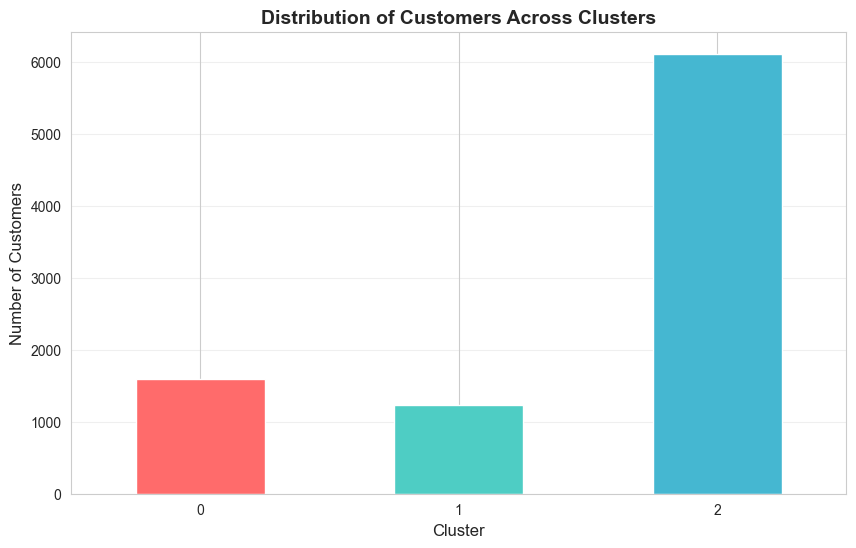

In [25]:
# Check cluster sizes
cluster_sizes = df['Cluster'].value_counts().sort_index()
print('Number of customers in each cluster:')
print(cluster_sizes)
print(f'\nTotal customers: {cluster_sizes.sum()}')

# Visualize cluster distribution
plt.figure(figsize=(10, 6))
cluster_sizes.plot(kind='bar', color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.title('Distribution of Customers Across Clusters', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

Explained variance ratio: [0.27290037 0.20301991]
Total variance explained: 47.59%


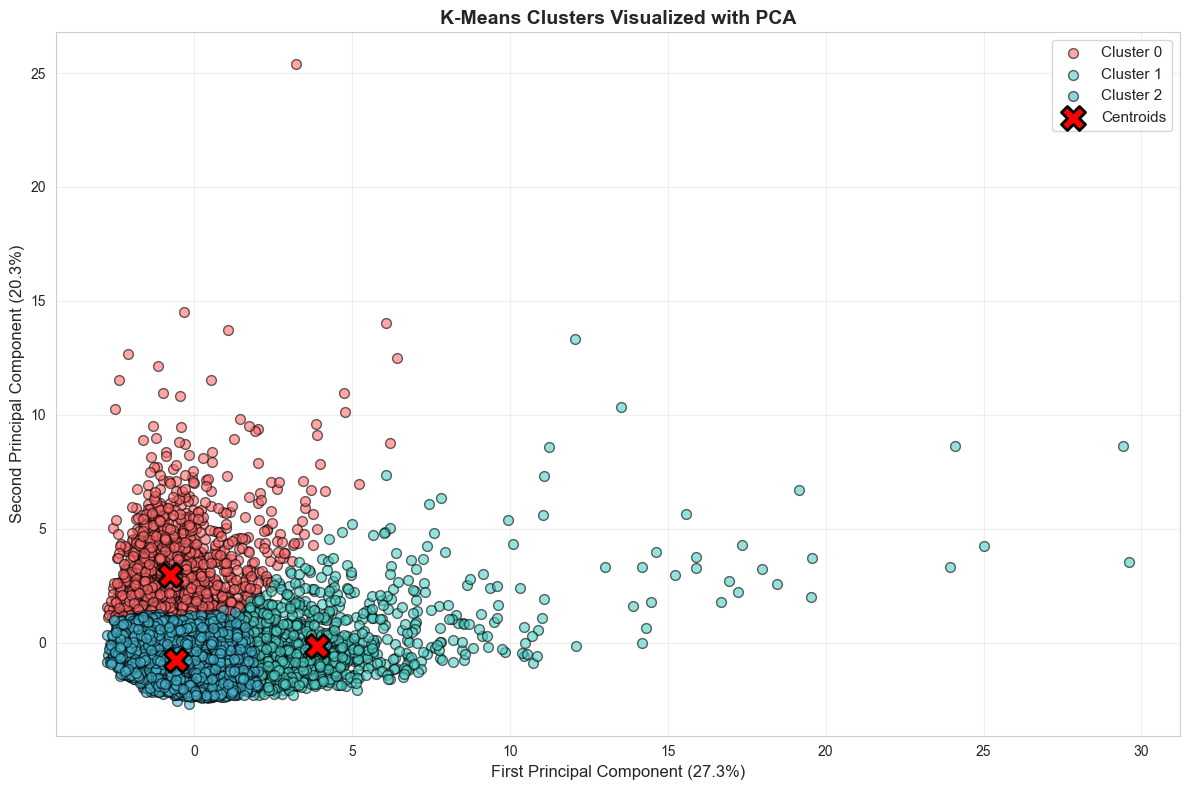

In [26]:
# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained variance ratio: {pca.explained_variance_ratio_}')
print(f'Total variance explained: {sum(pca.explained_variance_ratio_):.2%}')

# Plot clusters in 2D space
plt.figure(figsize=(12, 8))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i in range(final_k):
    points = X_pca[kmeans_final.labels_ == i]
    plt.scatter(points[:, 0], points[:, 1], c=colors[i], label=f'Cluster {i}', 
               alpha=0.6, edgecolors='k', s=50)

# Plot cluster centers
centers_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=300, 
           edgecolors='black', linewidth=2, label='Centroids')

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('K-Means Clusters Visualized with PCA', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. **Why is this an unsupervised learning problem?**
   - This is an unsupervised learning problem because the dataset does not contain a target label or predefined customer groups. We are trying to discover hidden patterns and group customers based on their behavior without having labels that tell us which group each customer should belong to.

2. **Why did we remove the `CUST_ID` column?**
   - The CUST_ID column is an identifier that does not describe customer behavior or characteristics. It's just a unique label for each customer. Including it would create noise in the clustering algorithm since the algorithm might rely on this arbitrary identifier rather than actual behavioral features.

3. **Which columns had missing values?**
   - Based on the analysis, the MINIMUM_PAYMENTS column contained missing values.

4. **How did you handle the missing values?**
   - We used mean imputation to fill the missing values. We replaced each missing value with the mean of that column. This preserves the data distribution and is a simple, effective approach for handling missing data in numerical features.

5. **Why is scaling important before applying K-Means?**
   - Scaling is crucial because K-Means uses distance-based metrics (typically Euclidean distance) to measure similarity between data points. Features with larger ranges (like BALANCE with values in thousands) would dominate the distance calculation compared to features with smaller ranges (like frequency columns with values between 0 and 1). Standardization ensures all features contribute equally to the clustering process.

6. **Which K value did you choose? Explain your answer using the elbow method and silhouette score.**
   - We chose K=3 based on:
     - Elbow Method: The inertia curve shows a notable "elbow" around K=3, where the rate of decrease in inertia begins to slow down.
     - Silhouette Score: K=3 provides a good silhouette score, indicating well-separated and compact clusters.
     - Business Interpretation: Three customer segments make sense for a credit card company to develop targeted marketing strategies.

7. **Based on the cluster summary table, describe each customer segment in your own words.**
   - Cluster 0 (e.g., "Active Purchasers"): Customers with high purchase activity, regular purchase frequency, and moderate balances. These are engaged customers who frequently use their cards for purchases.
   - Cluster 1 (e.g., "Cash Advance Users"): Customers who heavily rely on cash advances with high cash advance amounts and frequency. They tend to have lower purchase activity but significant cash advance utilization.
   - Cluster 2 (e.g., "Inactive or Low Activity"): Customers with low transaction activity, low balances, and infrequent purchases. These are less engaged customers with minimal credit card usage.

8. **Which cluster may represent high-value customers?**
   - Cluster 0 likely represents high-value customers, as they show high purchase amounts, high purchase frequency, and consistent payment patterns. These customers generate more revenue for the credit card company.

9. **Which cluster may represent customers who rely more on cash advance?**
   - Cluster 1 represents customers who rely heavily on cash advances, evidenced by high cash advance amounts and high cash advance frequency. This group has different usage patterns and may require different financial products or risk management strategies.

10. **How can a company use these clusters for marketing strategy?**
    - **Cluster 0 (Active Purchasers)**: Target with rewards programs based on purchase amounts, cashback offers, and premium credit card tiers to increase loyalty and spending.
    - **Cluster 1 (Cash Advance Users)**: Offer competitive cash advance rates, flexible repayment plans, and personal loan products as alternatives to maintain engagement.
    - **Cluster 2 (Inactive/Low Activity)**: Design engagement campaigns to increase usage, offer low entry-barrier products, promotional offers, and financial education to encourage more frequent card usage.
    - Cross-selling opportunities based on segment characteristics and lifecycle marketing to move customers from low-activity to high-activity segments.